In [104]:
import os
import json
import yaml
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from umap.umap_ import UMAP
import seaborn as sns
from huggingface_hub import login
from datasets import load_dataset, Dataset
from scipy.stats import pearsonr, pointbiserialr

### Definition (lookup formal definitions)
- point-biserial r - measures the correlation between a discrete variable and some continuous scores
    - for every trait (for ex: extroversion) 
        - continuous: extroversion scores for each persona
        - one hot vector for the answers on the extrovesion option for the SJTs (whether it was picked or not, 0 and 1)
        - correlation between these (we want it to be positive, if the extraversion score is higher)
        - 

In [40]:
with open('../configs/generation_config.yaml', 'r') as file:
    generation_config = yaml.safe_load(file)
        
with open('../psychometric_tests/hexaco_100_eval.yaml', 'r') as file:
    hexaco_eval = yaml.safe_load(file)

In [53]:
trait_map = {
    "1": "Honesty-Humility",
    "2": "Emotionality",
    "3": "Extraversion",
    "4": "Agreeableness",
    "5": "Conscientiousness",
    "6": "Openness"
}

trait_list = ['honest-humility','emotionality','extraversion','agreeableness','conscientiousness','openness to experience','altruism']

In [13]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def load_sjt(sjt_dir):
    sjt_list = []
    for file in os.listdir(sjt_dir):
        synthetic_sjt = read_json(os.path.join(sjt_dir, file))
        sjt_list += synthetic_sjt

    print(f"{len(sjt_list)} SJTs Loaded")
    return sjt_list

def get_model_name(filename, file_str):
    model_name = filename.replace("_sjt_answers_","").replace(".json","").replace(file_str,"")
    return model_name


In [14]:
def get_true_indices_v1(data):
    resolved_traits = []
    true_answer_indices = []
    for answer, shuffled_indices in zip(data["answers"][0], data['config']['answer_index'][0]):
        # assuming one list per persona
        # shuffled_indices = data["config"]["answer_index"]  # list of per-question shuffles

        # Map answers back to their intended trait meaning
        # resolved_traits = []
        # true_answer_indices = []
        # for ans, shuffle in zip(answer, shuffled_indices):
            # ans is the chosen index (1,2,3,...)
        # shuffle is the shuffled order of indices for this question
        true_index = str(shuffled_indices[int(answer)-1] + 1)  # get original index meaning
        if true_index in trait_map:
            resolved_traits.append(trait_map[true_index])
            true_answer_indices.append(true_index)
    
    return true_answer_indices, resolved_traits

def get_true_indices(data):
    resolved_traits = []
    true_answer_indices = []
    for answer, shuffled_indices in zip(data["answers"][0], data['config']['answer_index']):
        # assuming one list per persona
        # shuffled_indices = data["config"]["answer_index"]  # list of per-question shuffles

        # Map answers back to their intended trait meaning
        # resolved_traits = []
        # true_answer_indices = []
        # for ans, shuffle in zip(answer, shuffled_indices):
            # ans is the chosen index (1,2,3,...)
        # shuffle is the shuffled order of indices for this question
        true_index = str(shuffled_indices[int(answer)-1] + 1)  # get original index meaning
        if true_index in trait_map:
            resolved_traits.append(trait_map[true_index])
            true_answer_indices.append(true_index)
    
    return true_answer_indices, resolved_traits

def get_trait_distribution(data):
    
    true_answer_indices, resolved_traits = get_true_indices(data)
    
    trait_counts = Counter(resolved_traits)
    total = sum(trait_counts.values())
    
    trait_summary = {
        trait: {
            "count": trait_counts[trait],
            "proportion": round(trait_counts[trait] / total, 3) if total > 0 else 0
        }
        for index, trait in trait_map.items()
    }
    return [trait_summary[key]['proportion'] for key in trait_summary.keys()]

def get_trait_distribution_v1(data):
    
    true_answer_indices, resolved_traits = get_true_indices_v1(data)
    
    trait_counts = Counter(resolved_traits)
    total = sum(trait_counts.values())
    
    trait_summary = {
        trait: {
            "count": trait_counts[trait],
            "proportion": round(trait_counts[trait] / total, 3) if total > 0 else 0
        }
        for index, trait in trait_map.items()
    }
    return [trait_summary[key]['proportion'] for key in trait_summary.keys()]
        

In [41]:
def calculate_hexaco_score(trait, subtrait, answers, likert_scale = generation_config['likert_scale']):
    # answer_dict = {}
    answers = [answer if answer in likert_scale else "Do not wish to answer" for answer in answers]
    answers = pd.Series(answers)
    subtrait_dict = hexaco_eval[trait][subtrait]
    indices = [idx - 1 for idx in subtrait_dict['indices']]
    trait_answers = answers[indices]
    refused_answers = trait_answers[trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    non_refused_answers = trait_answers[~trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    answer_indices = [likert_scale.index(answer) + 1 for answer in non_refused_answers]
    # print(answer_indices)
    true_answer_indices = [6-idx if reverse else idx for idx,reverse in zip(answer_indices, subtrait_dict['reverse'])]
    
    # answer_dict['answer_indices'] = answer_indices
    # answer_dict['true_answer_indices'] = true_answer_indices
    # answer_dict['n_answered_questions'] = len(true_answer_indices)
    # answer_dict['n_refused_questions'] = len(refused_answers)
    # answer_dict['trait'] = trait
    # answer_dict['subtrait'] = subtrait
    # answer_dict['subtrait_score'] = np.round(np.mean(true_answer_indices).item(),3)
    return true_answer_indices

def get_trait_scores(answer,likert_scale = generation_config['likert_scale']):
    trait_score = []
    for trait in hexaco_eval.keys():
        for subtrait in hexaco_eval[trait].keys():
            trait_true_answer_indices = []
            trait_true_answer_indices.extend(calculate_hexaco_score(trait, subtrait, answer, likert_scale))
        
        trait_score.append(np.round(np.mean(trait_true_answer_indices).item(),3).item())
    return trait_score

In [17]:
factor_analysis_data_dir = "../experiment_results/factor_analysis_data/"

In [18]:
sjt_data = read_json(os.path.join(factor_analysis_data_dir, "huggingface_sjt_answers_Qwen2_5-7B-Instruct.json"))

hexaco_data = read_json(os.path.join(factor_analysis_data_dir, "huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json"))

In [45]:
sjt_trait_df = pd.DataFrame([{"persona_id": key, "answers": get_trait_distribution_v1(sjt_data[key])} for key in sjt_data.keys()])

sjt_trait_df = pd.DataFrame(sjt_trait_df['answers'].to_list(), columns = trait_map.values(), index = sjt_trait_df['persona_id'])

In [54]:
hexaco_df = pd.DataFrame([{"persona_id": key, "answers": hexaco_data[key]['answers'][0]} for key in hexaco_data.keys()])

hexaco_df = pd.DataFrame(hexaco_df['answers'].to_list(), columns = list(range(0,100)), index = hexaco_df['persona_id'])

hexaco_trait_df = pd.DataFrame(hexaco_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = hexaco_df.index, columns = trait_list)

In [70]:
sjt_trait_df.columns

Index(['Honesty-Humility', 'Emotionality', 'Extraversion', 'Agreeableness',
       'Conscientiousness', 'Openness'],
      dtype='object')

In [71]:
hexaco_cols = ['honest-humility', 'emotionality', 'extraversion', 'agreeableness',
       'conscientiousness', 'openness to experience']

sjt_cols = ['Honesty-Humility', 'Emotionality', 'Extraversion', 'Agreeableness',
       'Conscientiousness', 'Openness']

In [230]:
sjt_trait_df.describe()

,Honesty-Humility,Emotionality,Extraversion,Agreeableness,Conscientiousness,Openness
persona_id,,,,,,
782f13f4-0d98-41b4-a170-a2839dc6be70,0.408,0.036,0.026,0.194,0.180,0.156
81596279-9ae8-463f-bb93-f8f0f88d777e,0.422,0.040,0.016,0.130,0.276,0.116
6ce72d58-d03e-46d3-ae63-28b1bad56c26,0.444,0.032,0.018,0.124,0.272,0.110
e960e68a-f260-48df-8cb7-d6f8a46e470a,0.412,0.024,0.026,0.186,0.210,0.142
e3d265c4-b172-44f0-b058-be4d42fe5fb4,0.440,0.014,0.008,0.138,0.290,0.110
...,...,...,...,...,...,...
f9b3979a-8127-4f71-b225-df50c3dc9de0,0.436,0.022,0.030,0.164,0.220,0.128
46bfb1c8-0824-4cad-b244-2043935439e7,0.460,0.038,0.066,0.116,0.172,0.148
59e370ce-0bf6-433b-8ee8-cea32b94785a,0.434,0.030,0.050,0.136,0.196,0.154


In [73]:
for hex_col, sjt_col in zip(hexaco_cols, sjt_cols):
    print(hex_col)
    print(pearsonr(sjt_trait_df[sjt_col].T, hexaco_trait_df[hex_col].T))

honest-humility
PearsonRResult(statistic=np.float64(-0.12222256053172237), pvalue=np.float64(1.9957078090046312e-06))
emotionality
PearsonRResult(statistic=np.float64(0.21686589849246732), pvalue=np.float64(1.8192668556878844e-17))
extraversion
PearsonRResult(statistic=np.float64(0.5047402388237268), pvalue=np.float64(5.044903051406838e-98))
agreeableness
PearsonRResult(statistic=np.float64(0.3299024617216874), pvalue=np.float64(1.626040121238522e-39))
conscientiousness
PearsonRResult(statistic=np.float64(0.27740344735649247), pvalue=np.float64(5.626321186889764e-28))
openness to experience
PearsonRResult(statistic=np.float64(0.34352913548329256), pvalue=np.float64(6.5736787577891296e-43))


### Writing Hints
- HH is the most common answer, even if the trait is absent, the answer is picked, hence the odd effect of neg corr
- hexaco score for the persona, predicts the SJT trait preference as well
- mention pearson corr coef for first one, and biserial r for the second one

story is different
- pearson corr is comparing the aggregate persona hexaco profiles but the biserial one is doing item level measure

## Item Level Analysis

In [167]:
sjt_answers_df = pd.DataFrame([{"persona_id": key, "answers": get_true_indices_v1(sjt_data[key])[0]} for key in sjt_data.keys()])

sjt_answers_df = pd.DataFrame(sjt_answers_df['answers'].to_list(), columns = list(range(0,500)), index = sjt_answers_df['persona_id'])

In [168]:
def trait_to_binary(col, trait):
    trait_index = list(trait_map.values()).index(trait) + 1
    
    return np.where(col == str(trait_index),1,0)

### calculate avg point biserial r for every trait

In [224]:
def get_trait_biserial_metrics(df, sjt_trait, hexaco_trait):
    
    trait_binary_df = df.apply(lambda x: trait_to_binary(x,sjt_trait), axis = 0)
    
    biserial_coeff = trait_binary_df.apply(lambda x: pointbiserialr(x,hexaco_trait_df[hexaco_trait].values), axis = 0).T[0].describe()
    
    return biserial_coeff
    

In [225]:
for sjt_trait, hexaco_trait in zip(trait_map.values(), trait_list):
    
    print(f"Point Bi-Serial R Coeff for {sjt_trait}")
    print(get_trait_biserial_metrics(sjt_answers_df, sjt_trait, hexaco_trait))

Point Bi-Serial R Coeff for Honesty-Humility
count    471.000000
mean      -0.008669
std        0.043773
min       -0.167747
25%       -0.035401
50%       -0.005964
75%        0.017703
max        0.179212
Name: 0, dtype: float64
Point Bi-Serial R Coeff for Emotionality


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


count    224.000000
mean       0.026847
std        0.041740
min       -0.083853
25%        0.000887
50%        0.018071
75%        0.054088
max        0.174572
Name: 0, dtype: float64
Point Bi-Serial R Coeff for Extraversion
count    271.000000
mean       0.087161
std        0.064721
min       -0.046131
25%        0.037362
50%        0.076242
75%        0.123463
max        0.270383
Name: 0, dtype: float64
Point Bi-Serial R Coeff for Agreeableness


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


count    357.000000
mean       0.061912
std        0.057214
min       -0.062895
25%        0.023375
50%        0.056243
75%        0.095359
max        0.266188
Name: 0, dtype: float64
Point Bi-Serial R Coeff for Conscientiousness
count    465.000000
mean       0.048465
std        0.037486
min       -0.051789
25%        0.022315
50%        0.044470
75%        0.074311
max        0.174350
Name: 0, dtype: float64
Point Bi-Serial R Coeff for Openness


/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


count    339.000000
mean       0.040460
std        0.045186
min       -0.070030
25%        0.012891
50%        0.035022
75%        0.066464
max        0.197710
Name: 0, dtype: float64


### Logisitic Regression for persona base effect

- can the logisitic model predict sjt hexaco score as a function of the base hexaco score
- some kind of persona level bias term

In [ ]:
from statsmodels.api import OLS

In [233]:
hexaco_trait_df.drop('altruism', axis =1)/5

,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience
persona_id,,,,,,
782f13f4-0d98-41b4-a170-a2839dc6be70,0.7000,0.70,0.55,0.7000,0.85,0.6500
81596279-9ae8-463f-bb93-f8f0f88d777e,0.7334,0.70,0.50,0.6666,0.80,0.6666
6ce72d58-d03e-46d3-ae63-28b1bad56c26,0.7500,0.80,0.50,0.7500,0.90,0.6666
e960e68a-f260-48df-8cb7-d6f8a46e470a,0.6500,0.65,0.50,0.6500,0.80,0.6000
e3d265c4-b172-44f0-b058-be4d42fe5fb4,0.7334,0.80,0.45,0.5334,0.80,0.6000
...,...,...,...,...,...,...
f9b3979a-8127-4f71-b225-df50c3dc9de0,0.7500,0.75,0.55,0.7000,0.90,0.6666
46bfb1c8-0824-4cad-b244-2043935439e7,0.7334,0.75,0.60,0.4666,0.60,0.6500
59e370ce-0bf6-433b-8ee8-cea32b94785a,0.7500,0.70,0.55,0.5500,0.95,0.6666


In [240]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [244]:
def get_trait_lr_model(sjt_trait):
    
    print(f"Linear Regression Trait Model for {sjt_trait}")
    
    X = hexaco_trait_df.drop('altruism', axis =1)/5
    y = sjt_trait_df[sjt_trait].values

    model = OLS(y,X).fit()
    print(model.summary())
    
    y_pred = model.predict(X)
    print("R2 (model):", round(model.rsquared,4))
    print("corr(y,y_pred)^2:", round(np.corrcoef(y, y_pred)[0,1]**2,6))
    
    vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        })
    
    print(vif_data)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    skmodel = LinearRegression()
    cv_scores = cross_val_score(skmodel, X, y, cv=cv, scoring='r2')
    print("CV R2 (5-fold):", cv_scores, "mean:", np.mean(cv_scores))
    
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    X_s_sm = sm.add_constant(X_s)
    model_s = sm.OLS(y, X_s_sm).fit()
    print("Standardized coefficients (beta):")
    print(pd.Series(model_s.params[1:], index=X.columns).round(4))
    

In [245]:
for sjt_trait in trait_map.values():
    get_trait_lr_model(sjt_trait)

Linear Regression Trait Model for Honesty-Humility
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                          3.519e+04
Date:                Tue, 07 Oct 2025   Prob (F-statistic):                        0.00
Time:                        09:41:01   Log-Likelihood:                          2959.0
No. Observations:                1504   AIC:                                     -5906.
Df Residuals:                    1498   BIC:                                     -5874.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|   

### Discarded

Text(0.5, 1.0, 'Overall Trait Correlation Plot SJT - Qwen 2_5 7b')

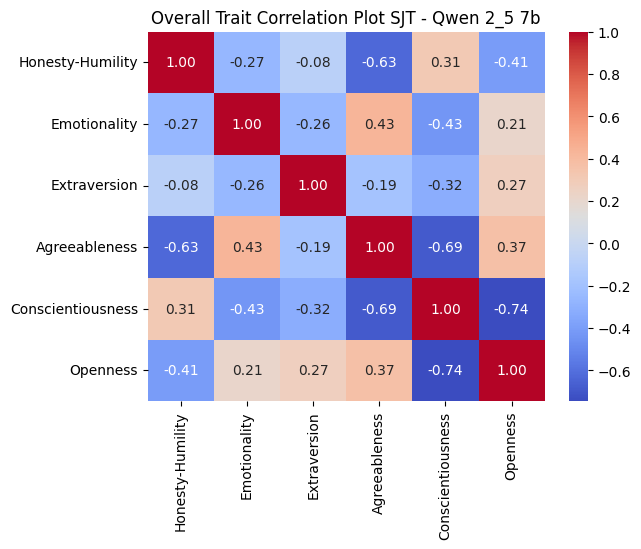

In [161]:
sns.heatmap(np.corrcoef((sjt_trait_df - sjt_trait_df.mean()).T), annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=trait_map.values(),yticklabels=trait_map.values())
plt.title(f"Overall Trait Correlation Plot SJT - Qwen 2_5 7b")

In [139]:
n_options = 6
sjt_answers_one_hot_df = pd.concat([
        pd.get_dummies(sjt_answers_df[col], prefix=col).reindex(
            columns=[f"{col}_{i+1}" for i in range(n_options)],
            fill_value=0
        )
        for col in sjt_answers_df.columns
    ], axis=1)

persona_sjt_answers_one_hot_df = sjt_answers_one_hot_df.astype(int)

persona_sjt_answers_normalized_df = (persona_sjt_answers_one_hot_df - persona_sjt_answers_one_hot_df.mean()) / persona_sjt_answers_one_hot_df.std()
persona_sjt_answers_normalized_df.fillna(0, inplace=True)

In [148]:
traits = sorted(set(col.split('_')[1] for col in persona_sjt_answers_normalized_df.columns))

# Compute row-wise mean for each trait index
trait_means = pd.DataFrame({
    f"trait_{trait}": persona_sjt_answers_normalized_df.filter(regex=fr"_{trait}$").mean(axis=1)
    for trait in traits
})
trait_means.columns = trait_map.values()

Text(0.5, 1.0, 'Overall Trait Correlation Plot SJT - Qwen 2_5 7b')

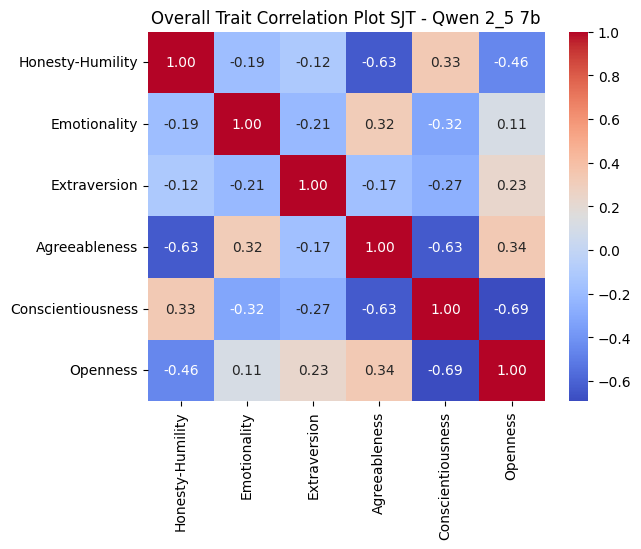

In [156]:
sns.heatmap(np.corrcoef(trait_means.T), annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=trait_map.values(),yticklabels=trait_map.values())
plt.title(f"Overall Trait Correlation Plot SJT - Qwen 2_5 7b")